In [16]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [17]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/Smart-Energy/feature_engineered_dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [3]:
import os

print(os.path.exists('/content/feature_engineered_dataset.csv'))


True


In [6]:
import pandas as pd

df = pd.read_csv('/content/feature_engineered_dataset.csv')

print(df.shape)

(2047446, 26)


In [7]:
print(df.columns.tolist())

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Timestamp', 'Datetime', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'Weekend', 'Lag_1', 'Lag_24', 'Lag_168', 'RollingMean_24', 'RollingStd_24', 'Difference', 'PctChange', 'Peak']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2047446 entries, 0 to 2047445
Data columns (total 26 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
 9   Timestamp              object 
 10  Datetime               object 
 11  Hour                   int64  
 12  Day                    int64  
 13  Month                  int64  
 14  DayOfWeek              int64  
 15  Week                   int64  
 16  Quarter                int64  
 17  Weekend                int64  
 18  Lag_1                  float64
 19  Lag_24                 float64
 20  Lag_168                float64
 21  RollingMean_24         float64
 22  RollingStd_24     

In [9]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime").reset_index(drop=True)

print(df["Datetime"].min())
print(df["Datetime"].max())

2006-12-16 20:12:00
2010-11-26 21:02:00


In [10]:
features = [
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "Hour",
    "Day",
    "Month",
    "DayOfWeek",
    "Week",
    "Quarter",
    "Weekend",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "RollingMean_24",
    "RollingStd_24",
    "Difference",
    "PctChange"
]

target = "Global_active_power"

data = df[features + [target]].copy()

print(data.shape)

(2047446, 21)


In [11]:
train_size = int(len(data) * 0.70)
val_size = int(len(data) * 0.15)

train_df = data[:train_size]
val_df = data[train_size:train_size + val_size]
test_df = data[train_size + val_size:]

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1433212, 21)
Validation: (307116, 21)
Test: (307118, 21)


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)

val_scaled = scaler.transform(val_df)

test_scaled = scaler.transform(test_df)

print("Scaling completed!")

Scaling completed!


In [13]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [14]:
window_size = 60
batch_size = 64

train_generator = TimeseriesGenerator(
    train_scaled[:, :-1],
    train_scaled[:, -1],
    length=window_size,
    batch_size=batch_size
)

val_generator = TimeseriesGenerator(
    val_scaled[:, :-1],
    val_scaled[:, -1],
    length=window_size,
    batch_size=batch_size
)

test_generator = TimeseriesGenerator(
    test_scaled[:, :-1],
    test_scaled[:, -1],
    length=window_size,
    batch_size=batch_size
)

In [18]:
model = Sequential([
    GRU(
        64,
        input_shape=(window_size, len(features))
    ),

    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,577 (64.75 KB)

 Trainable params: 16,577 (64.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [20]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 1261s 56ms/step - loss: 9.9663e-04 - val_loss: 5.0638e-04
Epoch 2/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 1249s 56ms/step - loss: 6.2749e-04 - val_loss: 4.6546e-04
Epoch 3/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 1244s 56ms/step - loss: 6.0515e-04 - val_loss: 5.6412e-04


In [21]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

In [22]:
print(history.history)

{'loss': [0.0009966251673176885, 0.000627493835054338, 0.0006051513482816517], 'val_loss': [0.0005063836579211056, 0.0004654558433685452, 0.000564123154617846]}


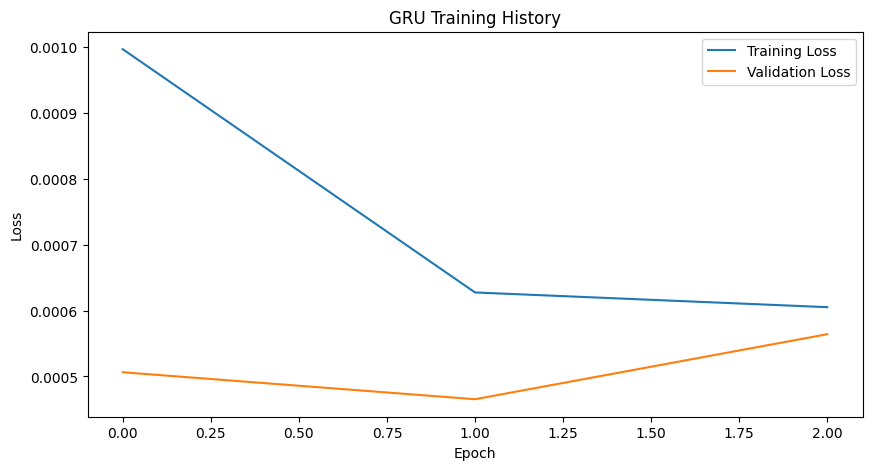

In [24]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('GRU Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [26]:
import os

os.makedirs("/content/reports/figures", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)

print("Folders Created")

Folders Created


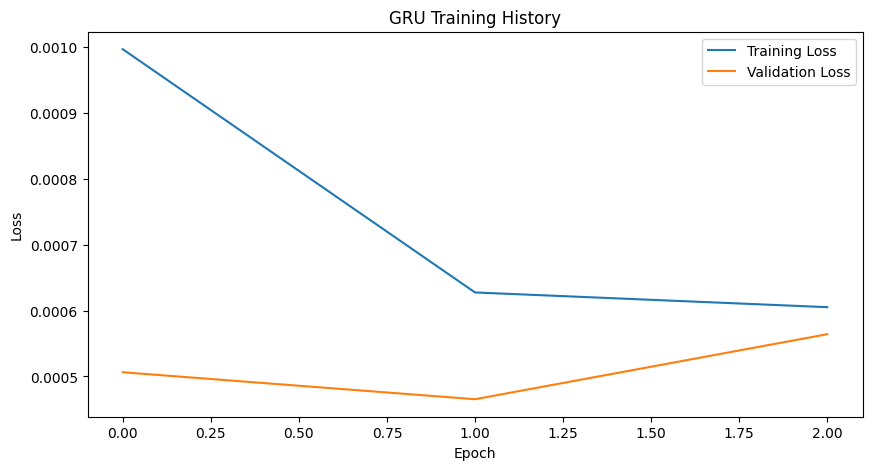

In [28]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("GRU Training History")

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig(
"/content/reports/figures/gru_training_history.png",
bbox_inches="tight"
)

plt.show()

In [29]:
predictions = model.predict(test_generator)

print(predictions.shape)

4798/4798 ━━━━━━━━━━━━━━━━━━━━ 77s 16ms/step
(307058, 1)


In [30]:
y_true = []

for _, y in test_generator:
    y_true.extend(y)

y_true = np.array(y_true)

print(y_true.shape)

(307058,)


In [31]:
y_pred = predictions.flatten()

print(y_pred.shape)

(307058,)


In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mape = np.mean(
    np.abs((y_true - y_pred) / y_true)
) * 100

r2 = r2_score(y_true, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R²  :", r2)

MAE : 0.008760638797322794
RMSE: 0.01921566221159998
MAPE: 20.116945842783114
R²  : 0.9393180079548461


In [33]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE", "R2"],
    "Value": [mae, rmse, mape, r2]
})

metrics_df

,Metric,Value
0,MAE,0.008761
1,RMSE,0.019216
2,MAPE,20.116946
3,R2,0.939318


In [35]:
import os

os.makedirs("/content/reports", exist_ok=True)
os.makedirs("/content/reports/figures", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)


In [37]:
metrics_df.to_csv(
"/content/reports/gru_metrics.csv",
index=False
)

In [38]:
model.save("models/gru_model.keras")

print("Model saved ")

Model saved 


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

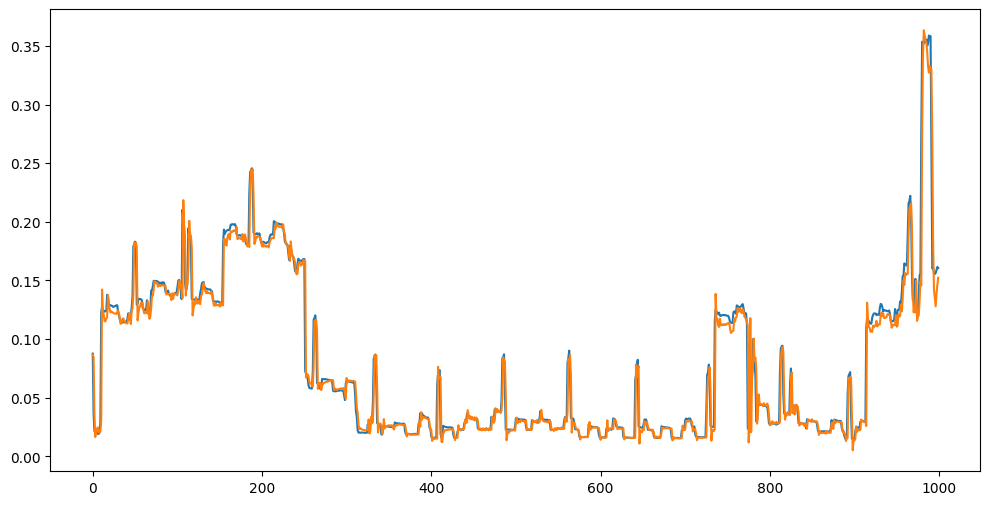

In [39]:
plt.figure(figsize=(12,6))

plt.plot(y_true[:1000], label="Actual")
plt.plot(y_pred[:1000], label="Predicted")

plt

In [41]:
import os

os.makedirs("/content/reports", exist_ok=True)
os.makedirs("/content/reports/figures", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)

print("Folders Created")

Folders Created


In [42]:
predictions_df = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred
})

predictions_df.to_csv(
"/content/reports/gru_predictions.csv",
index=False
)

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

tuned_model = Sequential([
    GRU(
        128,
        input_shape=(window_size, len(features))
    ),
    Dropout(0.3),
    Dense(1)
])

tuned_model.compile(
    optimizer="adam",
    loss="mse"
)

tuned_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 128)            │        57,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,729 (225.50 KB)

 Trainable params: 57,729 (225.50 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [48]:
tuned_history = tuned_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 2982s 133ms/step - loss: 8.5807e-04 - val_loss: 4.7806e-04
Epoch 2/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 2968s 133ms/step - loss: 6.3867e-04 - val_loss: 4.5762e-04
Epoch 3/3
22393/22393 ━━━━━━━━━━━━━━━━━━━━ 2948s 132ms/step - loss: 6.1143e-04 - val_loss: 4.5124e-04


In [49]:
tuned_predictions = tuned_model.predict(test_generator)

tuned_y_pred = tuned_predictions.flatten()

4798/4798 ━━━━━━━━━━━━━━━━━━━━ 185s 38ms/step


In [50]:
tuned_mae = mean_absolute_error(y_true, tuned_y_pred)

tuned_rmse = np.sqrt(
    mean_squared_error(y_true, tuned_y_pred)
)

tuned_mape = np.mean(
    np.abs((y_true - tuned_y_pred) / y_true)
) * 100

tuned_r2 = r2_score(
    y_true,
    tuned_y_pred
)

print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("MAPE:", tuned_mape)
print("R²  :", tuned_r2)

MAE : 0.00800084570711245
RMSE: 0.018832596413455062
MAPE: 16.247573949039577
R²  : 0.9417132934280484


In [51]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline GRU", "Tuned GRU"],
    "MAE": [mae, tuned_mae],
    "RMSE": [rmse, tuned_rmse],
    "MAPE": [mape, tuned_mape],
    "R2": [r2, tuned_r2]
})

comparison_df

,Model,MAE,RMSE,MAPE,R2
0,Baseline GRU,0.008761,0.019216,20.116946,0.939318
1,Tuned GRU,0.008001,0.018833,16.247574,0.941713


In [53]:
import os

os.makedirs("/content/reports", exist_ok=True)
os.makedirs("/content/reports/figures", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)


In [54]:
comparison_df.to_csv(
    "/content/reports/gru_model_comparison.csv",
    index=False
)

In [56]:
import os

os.makedirs("/content/reports", exist_ok=True)
os.makedirs("/content/reports/figures", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)

print("Folders Created")

Folders Created


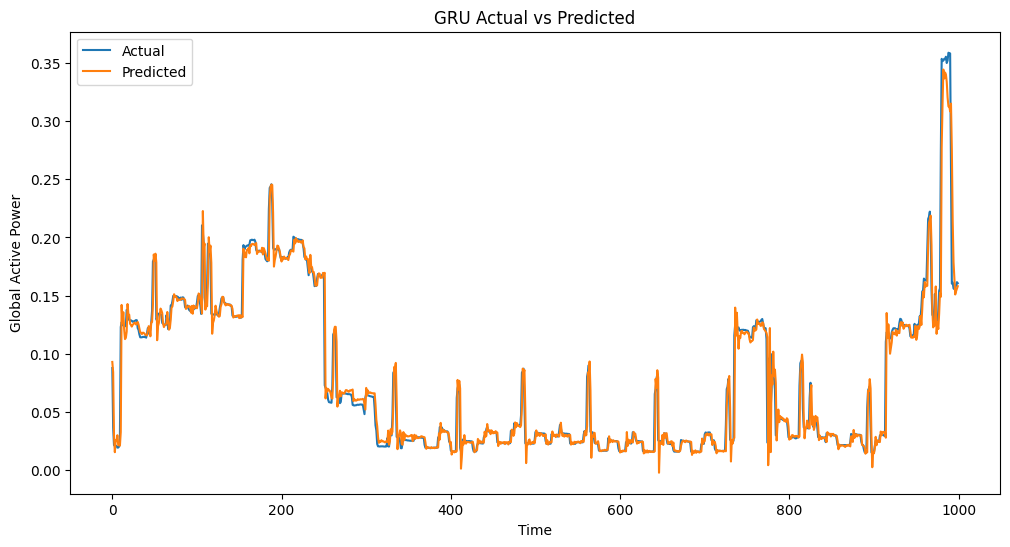

In [57]:
plt.figure(figsize=(12,6))

plt.plot(y_true[:1000], label="Actual")
plt.plot(tuned_y_pred[:1000], label="Predicted")

plt.title("GRU Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Global Active Power")

plt.legend()

plt.savefig(
    "/content/reports/figures/gru_actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()